Для аналізу та побудови моделі був взятий датасет по penguins.

### EDA

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('penguins.csv')

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [25]:
df.loc[df.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


Як бачимо, датасет має пропуски, але ці пропуски завжди також стосуються цільової змінної. Для EDA і тренування дропнемо всі 11 рядків. Але в кінці зробимо на прогноз на 9 meaningful записах (всі, крім 3 і 339)

In [26]:
df_temp = df.loc[df.isna().any(axis=1)]
df_for_end_predict = df_temp[~df['bill_length_mm'].isna()].drop(['sex'], axis=1)

In [27]:
df_clean = df.dropna()

In [28]:
df_clean[['species', 'sex']].value_counts()

species    sex   
Adelie     FEMALE    73
           MALE      73
Gentoo     MALE      61
           FEMALE    58
Chinstrap  FEMALE    34
           MALE      34
Name: count, dtype: int64

Бачимо рівномірний розподіл таргетної змінної всередині ознаки species

In [21]:
df_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


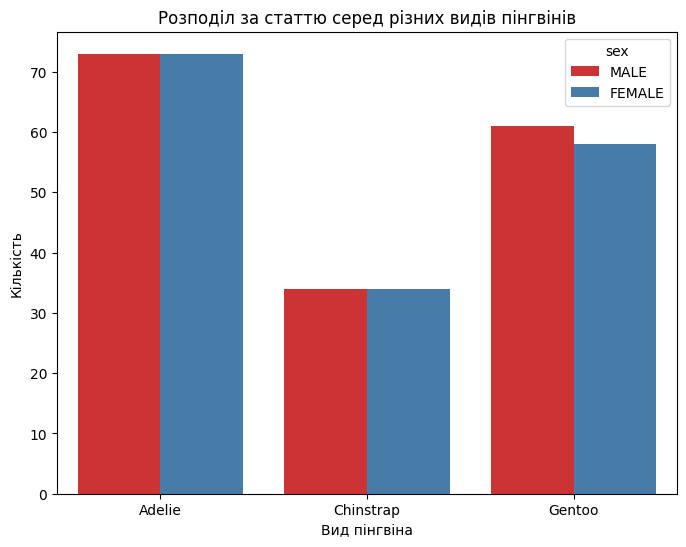

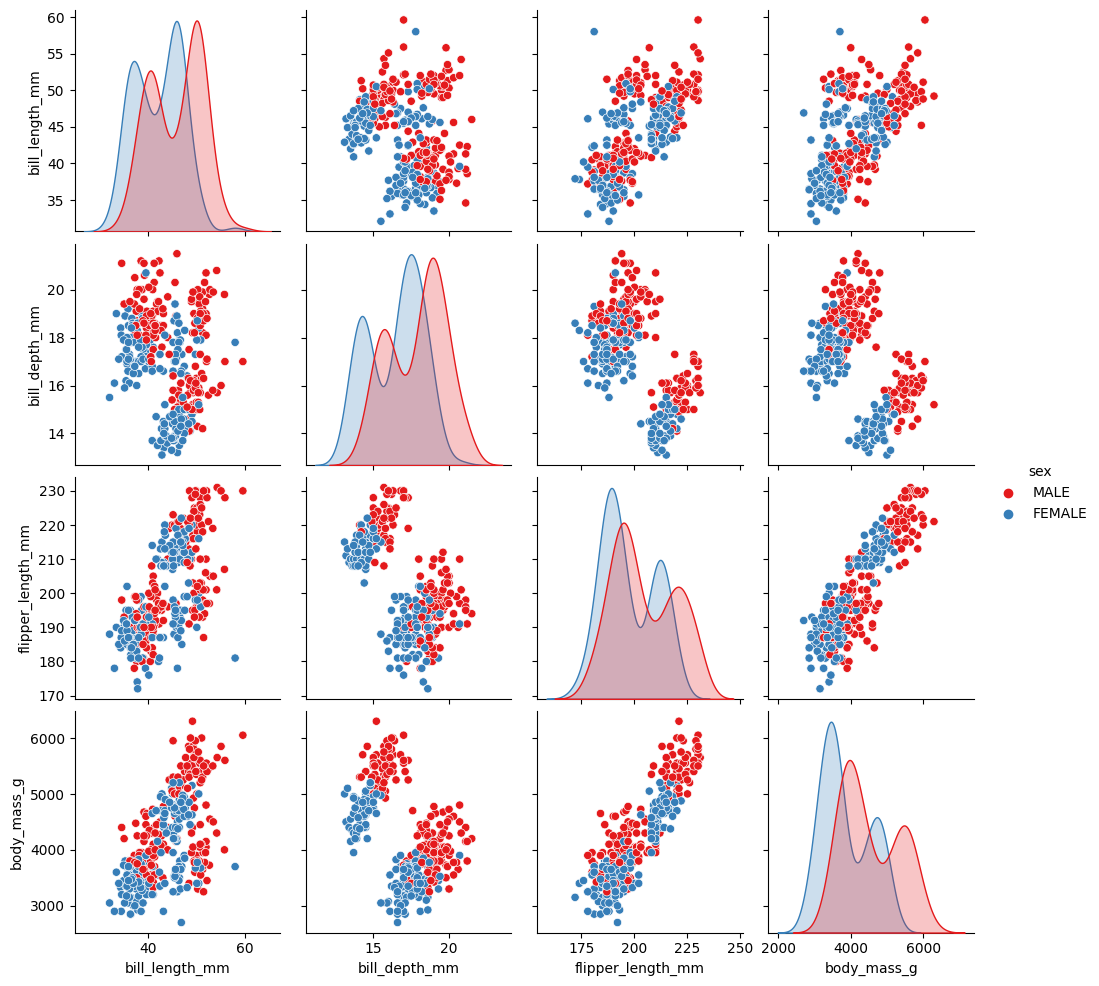

In [32]:
# EDA Plots
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='species', hue='sex', palette='Set1')
plt.title('Розподіл за статтю серед різних видів пінгвінів')
plt.xlabel('Вид пінгвіна')
plt.ylabel('Кількість')
plt.show()

sns.pairplot(df_clean, hue='sex', palette='Set1', diag_kind='kde')
plt.show()

Баланс класів є ідеальним — у вибірці приблизно порівну самців і самок. Аналіз діаграм розсіювання показав чітку закономірність, що самці статистично мають більшу масу тіла та більші розміри дзьобів (особливо глибину) порівняно з самками свого ж виду. Проте, оскільки різні види мають суттєво різні розміри загалом (наприклад, самка Gentoo часто більша за самця Adelie), розподіли двох статей на загальному графіку частково перекриваються. Це означає, що для точного визначення статі моделі обов'язково потрібно враховувати не лише фізичні параметри, а й вид пінгвіна, що робить цю задачу ідеальною для логістичної регресії.

### Тренування моделі

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_clean.drop('sex', axis=1)
y = df_clean['sex']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_cols = ['species', 'island']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['species', 'island'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

Classification report:
               precision    recall  f1-score   support

      FEMALE       0.93      0.85      0.89        33
        MALE       0.86      0.94      0.90        34

    accuracy                           0.90        67
   macro avg       0.90      0.89      0.90        67
weighted avg       0.90      0.90      0.90        67



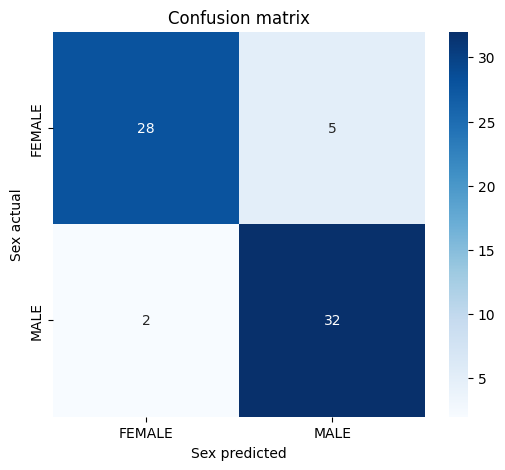

In [36]:
y_pred = pipeline.predict(X_test)

print("Classification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.xlabel('Sex predicted')
plt.ylabel('Sex actual')
plt.title('Confusion matrix')
plt.show()

Модель логістичної регресії дуже успішно впоралася із завданням, досягши точності 90%. Матриця помилок показує, що з 67 пінгвінів у тестовій вибірці модель помилилася лише кілька разів, що є відмінним результатом, враховуючи природні відхилення в розмірах тварин. Спробуємо також застосувати GridSearch.

Best params: {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}
Classification report:
               precision    recall  f1-score   support

      FEMALE       0.86      0.76      0.81        33
        MALE       0.79      0.88      0.83        34

    accuracy                           0.82        67
   macro avg       0.83      0.82      0.82        67
weighted avg       0.83      0.82      0.82        67



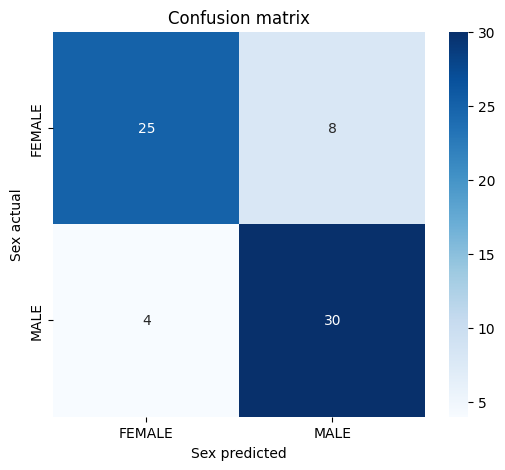

In [40]:
from sklearn.model_selection import GridSearchCV


# GridSearch
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0], 
    'classifier__solver': ['lbfgs', 'liblinear']  
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1')

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(f"Best params: {grid_search.best_params_}")

y_pred = best_model.predict(X_test)

print("Classification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel('Sex predicted')
plt.ylabel('Sex actual')
plt.title('Confusion matrix')
plt.show()

Після використання GridSearchCV точність на тестовій вибірці дещо знизилась. Це є очікуваним наслідком крос-валідації, оскільки GridSearch обрав гіперпараметри, які дають найбільш стабільний результат на різних фолдах тренувальної вибірки (уникаючи перенавчання). Хоча на конкретному тестовому наборі дефолтні параметри показали випадково вищий результат, модель після GridSearch є більш стійкою та краще генералізує дані для реального використання.

In [41]:
final_predictions = best_model.predict(df_for_end_predict)

df_results = df_for_end_predict.copy()
df_results['predicted_sex'] = final_predictions

df_results

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,predicted_sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,FEMALE
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,MALE
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,FEMALE
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,FEMALE
47,Adelie,Dream,37.5,18.9,179.0,2975.0,FEMALE
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,FEMALE
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,FEMALE
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,FEMALE
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,MALE


І предікт на небаченому до цього датасеті)